# eBOSS post-starburst analysis

In this second notebook, we visualze results from our post-starburst galaxy selection methods outlined in `01_eBOSS_classification.ipynb`. 

In [1]:
import numpy as np                                # to do math
import matplotlib.pyplot as plt                   # plotting functions
import pandas as pd                               # table format
import os                                         # universal os
from astroquery.sdss import SDSS                  # to query SDSS spectra
import astropy.units as u                         # convenient unit conversion
from scipy.ndimage import median_filter

## Loading data

In [2]:
data_folder_name = 'classified_sample'  
filename = 'classified_eBOSS_sample.csv'  # subsample we previously generated from the eBOSS parent sample

# accessing file from current directory
file_path = os.path.join('..', data_folder_name, filename)
file_path

'../classified_sample/classified_eBOSS_sample.csv'

In [3]:
# opening the .csv file as a DataFrame
classified_eBOSS_sample = pd.read_csv(file_path)
classified_eBOSS_sample

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,...,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,SN_MEDIAN_ALL,PLATE_weights,MJD_weights,FIBER_weights,Z_weights,FIT_WTS,PSB_CLASS
0,3586,55181,19,03586-55181-0019,0.684207,0.000181,9.406927,0.079718,-999.000000,0.054487,...,1.691677,0.046218,U,3.459556,3586,55181,19,0.684207,[[0.0000000e+00 3.6544303e-04 0.0000000e+00 0....,non_PSB
1,3586,55181,24,03586-55181-0024,0.266435,0.000042,9.222670,-0.430503,0.003912,0.099147,...,2.016093,0.035864,U,11.969681,3586,55181,24,0.266435,[[3.7599953e-06 0.0000000e+00 0.0000000e+00 0....,non_PSB
2,3586,55181,70,03586-55181-0070,0.592989,0.000133,9.148379,-0.157341,-999.000000,7.799566,...,1.907557,0.054590,U,4.780837,3586,55181,70,0.592989,[[0.0000000e+00 6.1418914e-04 0.0000000e+00 0....,non_PSB
3,3586,55181,77,03586-55181-0077,0.200669,0.000036,9.052210,0.078117,7.655054,2.446812,...,1.866302,0.065347,C,7.642647,3586,55181,77,0.200669,[[4.43300223e-06 5.22819028e-06 0.00000000e+00...,non_PSB
4,3586,55181,82,03586-55181-0082,0.304521,0.000038,8.816615,-1.214104,0.099873,0.030221,...,2.188409,0.039660,U,11.311866,3586,55181,82,0.304521,[[1.1543836e-05 0.0000000e+00 0.0000000e+00 0....,non_PSB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234840,12547,58928,936,12547-58928-0936,0.408284,0.000018,140.501765,2.110964,53.186546,7.856702,...,2.176021,0.062460,C,4.870236,12547,58928,936,0.408284,[[0.0000000e+00 4.4480755e-04 0.0000000e+00 0....,non_PSB
234841,12547,58928,945,12547-58928-0945,0.349465,0.000055,140.698116,2.606493,8.348373,1.954871,...,2.046958,0.058667,U,5.898760,12547,58928,945,0.349465,[[1.2237544e-05 0.0000000e+00 0.0000000e+00 0....,non_PSB
234842,12547,58928,969,12547-58928-0969,0.245407,0.000034,140.776308,2.079829,11.331253,2.130804,...,1.922028,0.049768,A,8.880144,12547,58928,969,0.245407,[[1.3306558e-05 9.1805428e-05 0.0000000e+00 0....,non_PSB
234843,12547,58928,981,12547-58928-0981,0.089286,0.000015,141.047762,2.389383,9.507236,2.125244,...,1.858667,0.044732,C,17.648275,12547,58928,981,0.089286,[[2.1187961e-05 0.0000000e+00 0.0000000e+00 0....,non_PSB


## Redshift distribution of sample

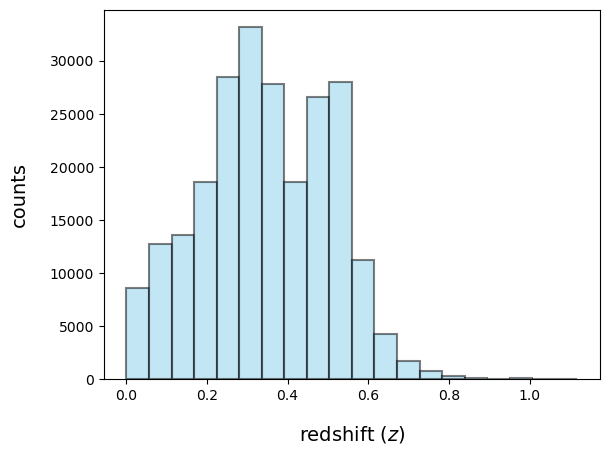

In [5]:
# initializing our figure
plt.figure()

# plotting data in a histogram
x_values = classified_eBOSS_sample['Z']
plt.hist(x_values, bins=20, alpha=0.5, color='skyblue', edgecolor='k', linewidth=1.5)

# labeling our axes
plt.xlabel(r'redshift ($z$)', fontsize=14, labelpad=15)
plt.ylabel('counts', fontsize=14, labelpad=15)

# saving and displaying figure
fig_name = 'redshift_distribution.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()
# UPDATE: with our new, larger data sample, our range of redshifts has increased greatly and we have a much larger number of high redshift galaxies included
# in our sample

Our sample consists of galaxies at $\, z\sim0-0.5$

## Visualizing our sample classifications

To make plotting simpler, we will split up our sample by post-starburst classification and save them in a dictionary

In [4]:
# splitting up our dataframe into these classifications
non_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='non_PSB']
classic_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='classic PSB']
young_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='young PSB']

interesting_galaxies = [(8832, 918), (4221, 271), (11376, 234), (8497, 723), (7711, 557), (10750, 178), 
(9166, 760), (11114, 28), (10747, 766), (7388, 794), (7639, 684), (8233, 695), (8530, 222), 
(8491, 740), (8360, 94), (8381, 531), (10912, 812), (10232, 822), (10925, 294), (7572, 656), (11565, 847), (7683, 349),
(11336, 284), (7306, 754), (7735, 154), (7279, 396), (10938, 81), (6262, 911), (5967, 311), (8745, 354), (6453, 775)]
interesting_classified = classified_eBOSS_sample[
    classified_eBOSS_sample.set_index(['PLATE', 'FIBER']).index.isin(interesting_galaxies)
]

# and saving as a dictionary
sample_dict = {'non-PSB': non_psb_sample, 'classic PSB': classic_psb_sample, 'young PSB': young_psb_sample, 'interesting galaxies': interesting_classified}
color_dict = {'non-PSB': '#2995ff', 'classic PSB': '#ffb327', 'young PSB': '#55d655', 'interesting galaxies': '#FF0000'}  # mapping colors for plotting

Let's compute the classification percentages for our sample

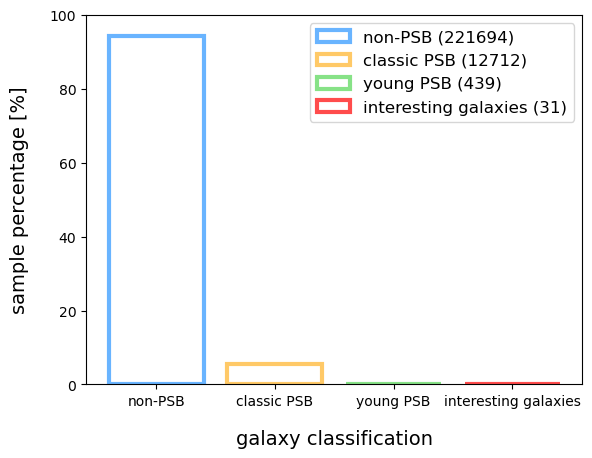

In [5]:
# initializing our figure
plt.figure()

labels = []
for i, key in enumerate(sample_dict):

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]
    data_label = key+f' ({len(subsample_data)})'

    # computing percentage
    counts = len(subsample_data)
    total = len(classified_eBOSS_sample)
    perc = 100 * counts / total

    # plotting data in a bar plot
    x_values = i     # given index of classification (0,1,2)
    y_values = perc  # associated percentage
    plt.bar(x_values, y_values, alpha=0.7, facecolor='none', edgecolor=subsample_color, linewidth=3, label=data_label)

# adding tick labels
labels = list(sample_dict.keys())
positions = np.arange(len(labels))
plt.xticks(positions, labels)

# scaling y-axis
plt.ylim(0,100)

# labeling our axes
plt.xlabel('galaxy classification', fontsize=14, labelpad=15)
plt.ylabel('sample percentage [%]', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'classification_distribution.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

## Visualizing Spectral Properties of Sample

### Past SFR vs recent SFR

We can probe different timescales of star-formation using the relationship between $H\alpha$ equivalent width and $H\delta_A$. Both of these measurements probe star formation on $\sim10$ Myr and $\sim1$ Gyr timescales, respectively.

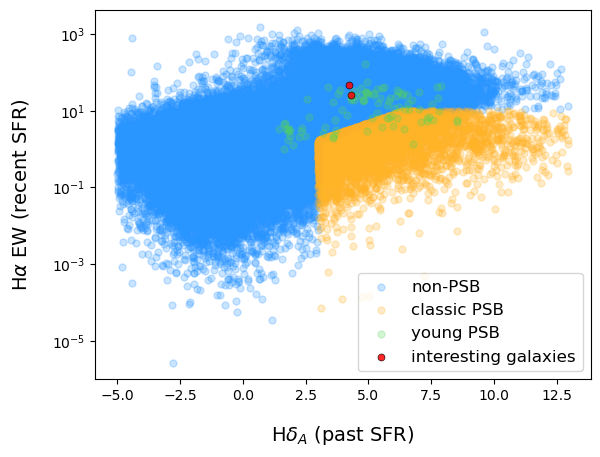

In [6]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # Filtering out all of the -999 H-alpha galaxies so our plot isn't affected by them
    valid_data = subsample_data[subsample_data['H_ALPHA_EW'] >= -10]

    # plotting data in a scatter plot
    x_values = valid_data['LICK_HDA']
    y_values = valid_data['H_ALPHA_EW']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel(r'H$\delta_{A}$ (past SFR)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\alpha$ EW (recent SFR)', fontsize=14, labelpad=15)
plt.yscale('log') 
plt.legend(fontsize=12, loc='lower right')

# saving and displaying figure
fig_name = 'H_delta_vs_H_alpha.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

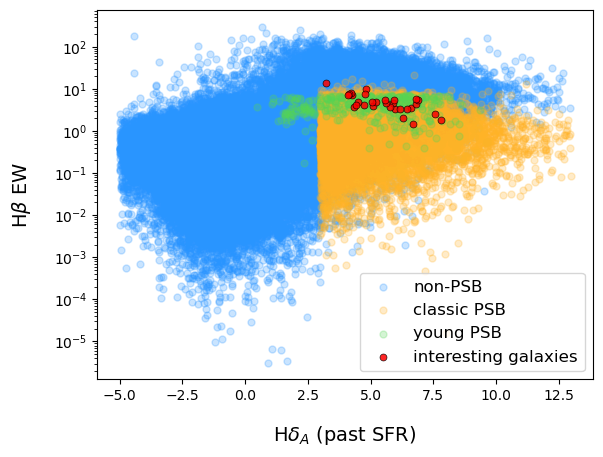

In [9]:
# H-delta by H-beta plot for the many galaxies that have no H-alpha data avaliable 
plt.figure()

for key in sample_dict:

    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # I am cutting out all invalid H-beta galaxies here as well, and setting the upper bound
    # of h-beta to 1500 because we have one random galaxy when an h-beta value of like 25000 that
    # is throwing off the plot.
    valid_data = subsample_data[(subsample_data['H_BETA_EW'] >= -10) & (subsample_data['H_BETA_EW'] <= 1500)]

    x_values = valid_data['LICK_HDA']
    y_values = valid_data['H_BETA_EW']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

plt.xlabel(r'H$\delta_{A}$ (past SFR)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\beta$ EW', fontsize=14, labelpad=15)
plt.yscale('log') 
plt.legend(fontsize=12, loc='lower right')

fig_name = 'H_delta_vs_H_beta.png'  
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Post-starbursts are theorized to lie in the bottom right corner of this diagram. These galaxies exhibit a lower $H\alpha$ nebular emission than expected for the strength of their Balmer absorption lines (i.e., $H\delta$). This selection allows us to include galaxies in the process of shutting down their SF. Below, I show this diagram taken from the literature (French+2016). 

<img src="../plots/French+2016_presentation_slide.png" width="600">

### Stellar population age

Next, we will look at the "Balmer Break" and the "4000 Å Break" measurements in galaxy spectra. 

These measurements probe the **temperature of stars** in a galaxy. According to the Hertzsprung-Russell Diagram, a star's temperature is correlated with its spectral type (i.e., O, B, A, ... etc.). Given a newly-formed population of stars, there will be a distribution of spectral types. After the stellar population has aged $\sim 10$ Myrs, the hotter/bluer stars (O and B stars) will die off before the cooler/redder stars. This will change the shape of the spectrum of the stellar population. Thus, the mean age of stellar populations in a galaxy can be determined by spectral features (e.g., the Balmer and 4000 Å Breaks) that trace any absence of young/hot/blue stars. 

Below are a handful of relationships using these breaks that will be useful to look at.

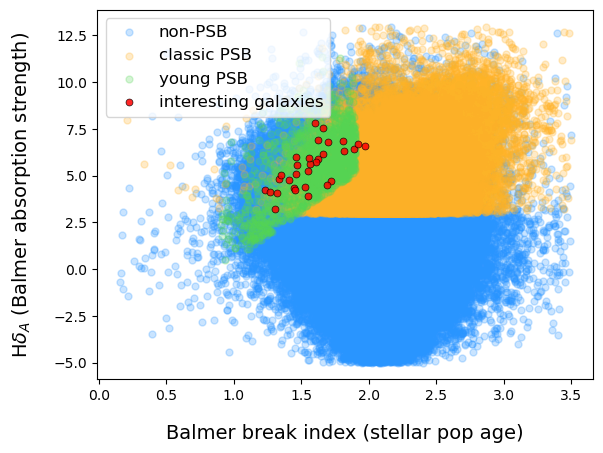

In [12]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['BALMERBREAK']
    y_values = subsample_data['LICK_HDA']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\delta_{A}$ (Balmer absorption strength)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper left')

# saving and displaying figure
fig_name = 'BalmerBreak_vs_H_delta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

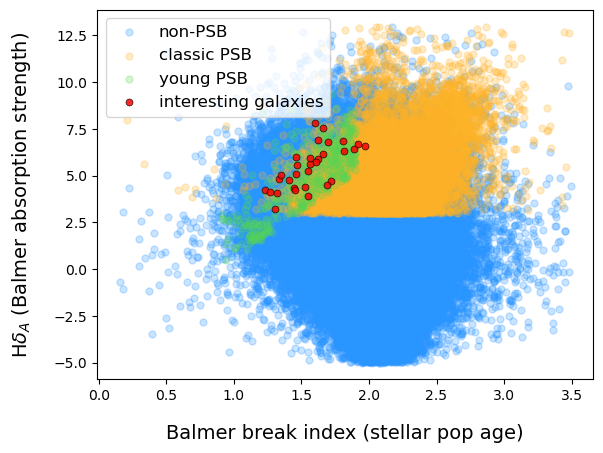

In [10]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['BALMERBREAK']
    y_values = subsample_data['LICK_HDA']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\delta_{A}$ (Balmer absorption strength)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper left')

# saving and displaying figure
fig_name = 'BalmerBreak_vs_H_delta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

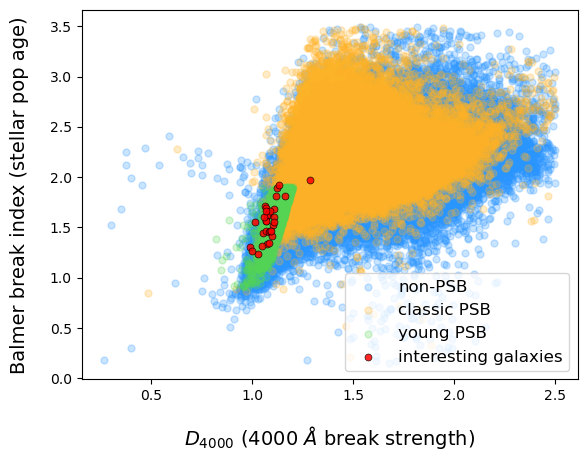

In [14]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['D_4000']
    y_values = subsample_data['BALMERBREAK']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel(r'$D_{4000}$ (4000 $\AA$ break strength)', fontsize=14, labelpad=15)
plt.ylabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='lower right')

# saving and displaying figure
fig_name = 'D_4000_vs_BalmerBreak.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

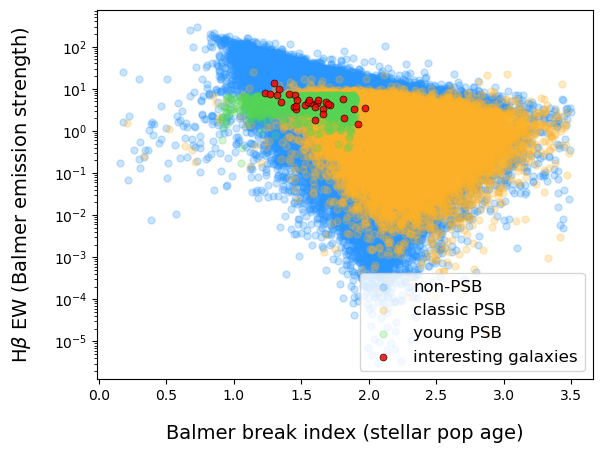

In [15]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # Once again we need to cut out the crazy H-beta reading of 25000 and any invalid h-beta readings
    valid_data = subsample_data[(subsample_data['H_BETA_EW'] >= -10) & (subsample_data['H_BETA_EW'] <= 1500)]

    # plotting data in a scatter plot
    x_values = valid_data['BALMERBREAK']
    y_values = valid_data['H_BETA_EW']
    
    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\beta$ EW (Balmer emission strength)', fontsize=14, labelpad=15)
plt.yscale('log') 
plt.legend(fontsize=12, loc='lower right')

# saving and displaying figure
fig_name = 'BalmerBreak_vs_H_beta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

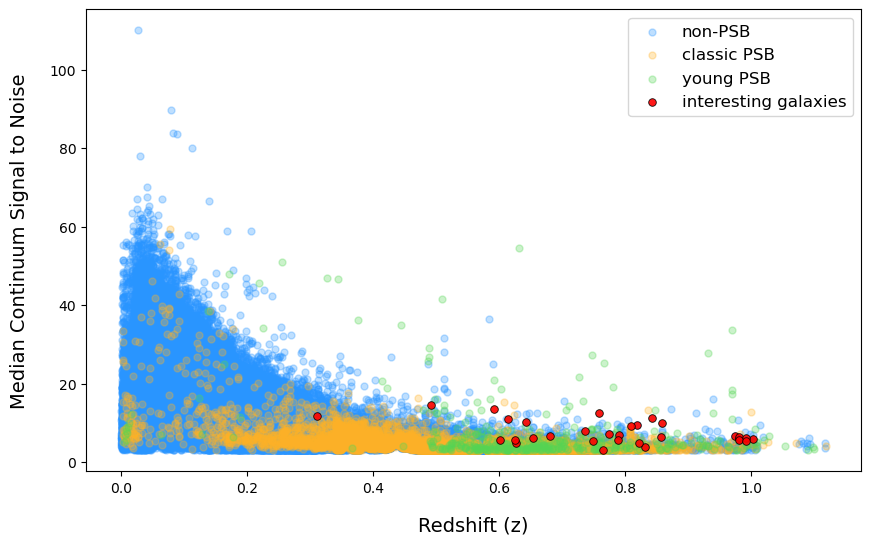

In [10]:
# UPDATE: Creating a signal to noise by redshift plot to help visualize where a lot of our outliars seem to be falling

plt.figure(figsize=(10, 6))

for key in sample_dict:

    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # Filtering out missing/invalid values if present (I just don't want to encounter issues with this down the road)
    valid_data = subsample_data[(subsample_data['SN_MEDIAN_ALL'] > 0) & (subsample_data['Z'] > 0)]

    # plotting data in a scatter plot
    x_values = valid_data['Z']
    y_values = valid_data['SN_MEDIAN_ALL']

    if key == "interesting galaxies":
        plt.scatter(x_values, y_values, s=30, alpha=0.9, c=subsample_color, edgecolors='black', linewidths=0.6, label=key, zorder=5)
    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.3, c=subsample_color, label=key, zorder=3)

# labeling our axes
plt.xlabel(r'Redshift (z)', fontsize=14, labelpad=15)
plt.ylabel(r'Median Continuum Signal to Noise', fontsize=14, labelpad=15)

plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'SN_vs_Redshift.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

### BPT diagram

This diagram classifies galaxies based on their inferred ionization source (the thing that is causing the emission that we measure). The eBOSS catalog has already classified galaxies on this diagram. So, we can take note of these classifications for our post-starbursts.

In [16]:
classified_eBOSS_sample['BPT_CLASS'].value_counts()

BPT_CLASS
U    370634
S     20063
L     15161
C      6492
A      3896
Name: count, dtype: int64

As shown above, these classifications include:
- `U` --> Unclassified ?
- `S` --> Star-forming ?
- `L` --> Liner ?
- `C` --> Composite ?
- `A` --> AGN ?

Let's see the number of galaxies in each classification for our sub-samples

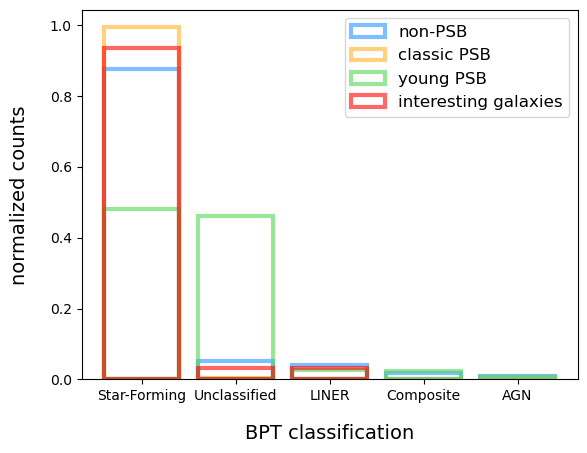

In [17]:
# initializing our figure
plt.figure()

for i, key in enumerate(sample_dict):

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a NORMALIZED bar plot
    y_values = subsample_data['BPT_CLASS'].value_counts(normalize=True)
    x_values = np.arange(len(y_values)) 
    
    plt.bar(x_values, y_values, alpha=0.6, facecolor='none', edgecolor=subsample_color, linewidth=3, label=key)

# adding tick labels
labels = ['Star-Forming', 'Unclassified', 'LINER', 'Composite', 'AGN']
positions = np.arange(len(labels))
plt.xticks(positions, labels)

# labeling our axes
plt.xlabel('BPT classification', fontsize=14, labelpad=15)
plt.ylabel('normalized counts', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'BPT_classification.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Below, we show where post-starbursts usually exist within the BPT classification scheme (French+2015). The "Seyferts" region contains galaxies with AGN. Post-starbursts exist everywhere except for the star-forming region, but primarily within the LINER region.

<img src="../plots/French+2015_figure.png" width="600">

## Spectra for galaxies in our sample

To obtain archival SDSS spectra, we will query the data using `astroquery`.

To pick a spectrum at random, we display a small range of galaxies for each classification. The range can be adjusted (i.e., `.iloc[0:10]`, `.iloc[10:20]`, `.iloc[20:30]`, etc...)

In [18]:
young_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,OII_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
760,3590,55201,604,03590-55201-0604,0.215379,0.000022,11.239422,0.437080,28.668991,5.842178,21.468350,1.162517,0.029732,6.361261,1.028214,1.881577,0.066426,S,young PSB
769,3590,55201,664,03590-55201-0664,0.251515,0.000041,11.896417,1.131122,40.569134,5.704706,29.611084,1.107485,0.040720,6.660887,1.469808,1.743894,0.084313,S,young PSB
1088,3609,55201,443,03609-55201-0443,0.601424,0.000096,30.228908,-1.191956,-999.000000,3.948385,8.228395,1.132672,0.042982,4.206986,1.277188,1.605225,0.077509,U,young PSB
2676,3647,55181,364,03647-55181-0364,0.108189,0.000020,36.636760,-1.218301,22.136515,5.327466,12.717567,1.146725,0.013745,7.146050,0.414954,1.533671,0.026846,S,young PSB
2856,3647,55241,486,03647-55241-0486,0.254104,0.000031,35.801304,-0.417721,20.283392,6.122954,12.003545,0.983393,0.024164,1.515243,1.056792,1.086622,0.029245,U,young PSB
3060,3647,55476,667,03647-55476-0667,0.643515,0.000058,36.534343,0.290868,-999.000000,6.679370,17.358604,1.155261,0.038871,6.175446,1.186977,1.627770,0.075498,U,young PSB
3139,3647,55827,113,03647-55827-0113,0.245131,0.000024,37.940310,-0.122340,33.704636,6.889617,20.890324,1.142577,0.031764,4.261713,1.086281,1.563121,0.054726,S,young PSB
3178,3647,55827,294,03647-55827-0294,0.074091,0.000014,36.858274,-1.172620,29.610420,5.547535,24.985708,1.144358,0.035850,7.576730,1.133433,1.598596,0.074315,S,young PSB
3384,3647,55945,627,03647-55945-0627,0.216932,0.000017,36.291548,1.175138,35.586315,6.650823,19.636398,1.177410,0.035003,6.751247,1.200747,1.865477,0.073770,S,young PSB
3706,3647,56596,96,03647-56596-0096,0.233605,0.000030,37.909847,-0.859428,29.247230,6.272605,19.082500,1.198085,0.043834,6.241031,1.350563,1.892122,0.096422,S,young PSB


In [15]:
classic_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
7,3587,55182,766,03587-55182-0766,0.013850,0.000062,9.132152,0.563281,7.500078,1.653817,1.273995,0.019915,6.042478,0.531182,1.726371,0.056440,S,classic PSB
38,3615,55179,962,03615-55179-0962,0.367720,0.000046,38.256082,0.461005,0.568509,0.348130,2.242338,0.047818,6.419164,0.522504,2.394710,0.051487,U,classic PSB
45,3615,55208,555,03615-55208-0555,0.391636,0.000120,36.150345,1.034750,1.887370,0.430450,1.337789,0.032270,9.816565,0.657004,2.763852,0.078619,U,classic PSB
46,3615,55208,574,03615-55208-0574,0.267958,0.000028,36.285573,0.395360,1.072568,0.083579,1.563180,0.014698,3.460790,0.325508,2.100727,0.023829,U,classic PSB
55,3615,55445,547,03615-55445-0547,0.391610,0.000120,36.150345,1.034750,0.827186,0.645192,1.336224,0.024198,9.336852,0.758258,2.750350,0.068406,U,classic PSB
56,3615,55445,570,03615-55445-0570,0.268079,0.000030,36.285573,0.395360,1.393927,0.424319,1.640177,0.017511,3.793898,0.364734,2.313181,0.029234,U,classic PSB
62,3615,55856,543,03615-55856-0543,0.391901,0.000117,36.150345,1.034750,1.582105,0.779335,1.325444,0.026742,9.227488,0.834052,2.679901,0.071183,U,classic PSB
75,3615,56544,505,03615-56544-0505,0.391852,0.000129,36.150345,1.034750,0.209617,0.342146,1.484955,0.024393,9.369776,0.609053,3.107601,0.070151,U,classic PSB
91,3647,55241,545,03647-55241-0545,0.391439,0.000151,36.150345,1.034750,0.607672,0.422795,1.304206,0.031138,9.531018,0.891700,2.844433,0.092504,U,classic PSB
97,3647,55476,505,03647-55476-0505,0.391664,0.000208,36.150345,1.034750,1.986870,0.320953,1.489730,0.027074,11.285812,0.841519,3.121819,0.080964,U,classic PSB


In [19]:
non_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,OII_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
0,3586,55181,2,03586-55181-0002,0.719691,0.000069,9.330078,-0.624116,-999.000000,6.830700,16.359863,1.237227,0.042098,6.937127,1.299937,1.611020,0.080973,U,non_PSB
2,3586,55181,19,03586-55181-0019,0.684207,0.000181,9.406927,0.079718,-999.000000,0.054487,1.097656,1.411507,0.030450,-0.123784,0.856371,1.691677,0.046218,U,non_PSB
3,3586,55181,24,03586-55181-0024,0.266435,0.000042,9.222670,-0.430503,0.003912,0.099147,2.933545,1.887702,0.032765,-1.343439,0.560995,2.016093,0.035864,U,non_PSB
5,3586,55181,70,03586-55181-0070,0.592989,0.000133,9.148379,-0.157341,-999.000000,7.799566,28.864552,1.407863,0.032552,2.349530,0.769089,1.907557,0.054590,U,non_PSB
6,3586,55181,77,03586-55181-0077,0.200669,0.000036,9.052210,0.078117,7.655054,2.446812,24.920921,1.628066,0.049999,-1.454230,1.047995,1.866302,0.065347,C,non_PSB
7,3586,55181,82,03586-55181-0082,0.304521,0.000038,8.816615,-1.214104,0.099873,0.030221,0.450624,1.859454,0.030917,-0.508241,0.553203,2.188409,0.039660,U,non_PSB
8,3586,55181,87,03586-55181-0087,0.723177,0.000130,8.796056,-0.940876,-999.000000,0.058906,1.475103,1.630242,0.043478,2.661919,0.822896,2.196094,0.087491,U,non_PSB
9,3586,55181,111,03586-55181-0111,0.341818,0.000047,8.923396,-0.129852,13.419834,8.734538,24.287663,1.302878,0.032718,5.212342,1.035912,1.879531,0.055606,L,non_PSB
10,3586,55181,112,03586-55181-0112,0.325795,0.000055,8.814932,-0.347207,4.353885,1.224293,19.776875,1.627713,0.058043,0.559687,1.437056,2.132319,0.086942,U,non_PSB
11,3586,55181,123,03586-55181-0123,0.704188,0.000236,8.636668,-1.122782,-999.000000,2.542963,0.112672,1.801184,0.083163,1.640502,1.489523,1.934919,0.128393,U,non_PSB


A galaxy's identification (`PMF_STRING`) can be used to query its spectrum.

In [21]:
# saving a galaxy using its PMF_STRING
source = young_psb_sample[young_psb_sample['PMF_STRING'] == '03841-56016-0890'].iloc[0]

# saving relevant information from the columns in that row
plate = int(source['PLATE'])
mjd   = int(source['MJD'])
fiber = int(source['FIBER'])
key = source['PMF_STRING']
z = source['Z']
classification = source['PSB_CLASS']

# displaying the galaxy info:
print('galaxy identification:', key)
print('galaxy classification:', classification)

galaxy identification: 03841-56016-0890
galaxy classification: young PSB


In [22]:
# ... this cell might take a minute to run ...

# try to query spectra from SDSS archive
try:

    # query
    spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber)

    if spec is not None:

        hdu = spec[0]  # header-data unit (hdu)

        # ----------- saving spectral data ------------

        # flux
        flux_density_factor = hdu[1].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
        flux_density = 10**(-17) * flux_density_factor  # [ergs / s / cm^2 / A]

        # flux error
        ivar = hdu[1].data['ivar']
        flux_density_err = np.zeros_like(flux_density)
        good = ivar > 0    # avoid dividing by zero
        flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])

        # wavelength
        log_wav = hdu[1].data['loglam']
        wavelength = 10**log_wav         # [A]

        # ----------------------------------------------

        print('successfully saved galaxy spectrum')

# if unable to find spectra, give exception
except Exception as e:
    print(f"Failed to retrieve spectrum for {key}: {e}")


successfully saved galaxy spectrum


In [19]:
# convert spectrum from observed frame to rest frame using the object's redshift
rest_frame_wavelength = wavelength / (1+z)
rest_frame_flux_density = flux_density * (1+z)
rest_frame_flux_density_err = flux_density_err * (1+z)

Now, let's see the spectrum !

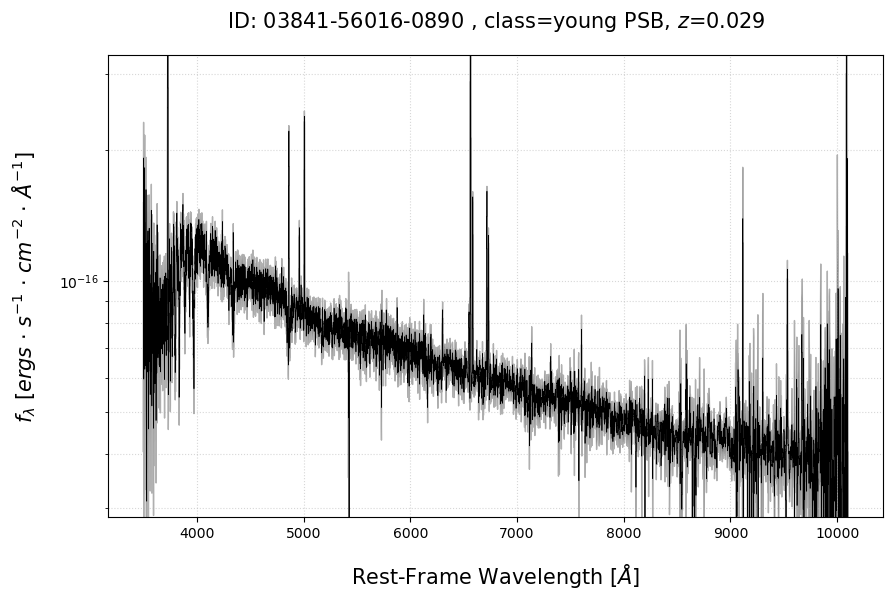

In [10]:
# initializing our figure
plt.figure(figsize=(10,6))

# labeling our axes
plt.title(f"ID: {key} , class={classification}, $z$={z:.3f}",fontsize=15, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# main spectral data
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.5)

# flux errors shown by shaded region
upper = rest_frame_flux_density + rest_frame_flux_density_err
lower = rest_frame_flux_density - rest_frame_flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.3)

# -------------------------------------------------------------------------
# Log scaling the y-axis
plt.yscale('log', nonpositive='clip')

# Forcing the y-axis limits to ignore noisy pixels or crazy outliers
positive_flux = rest_frame_flux_density[rest_frame_flux_density > 0]
if len(positive_flux) > 0:
    plt.ylim(np.percentile(positive_flux, 1), np.percentile(positive_flux, 99.5) * 2)

# Trying how adding a grid looks, we can always remove this feature
plt.grid(True, which="both", linestyle=":", alpha=0.5)
# -------------------------------------------------------------------------

# saving and displaying figure
fig_name = f'{key}_spectrum.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
# plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

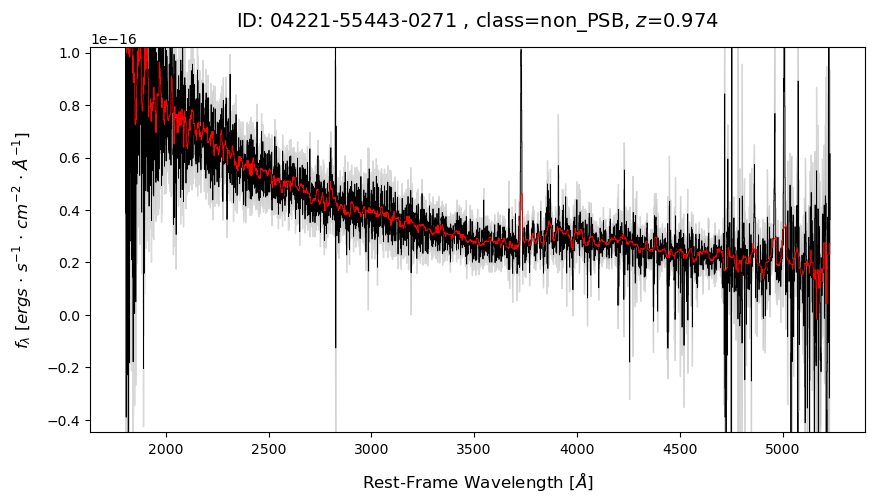

Successfully plotted 04221-55443-0271
--------------------------------------------------


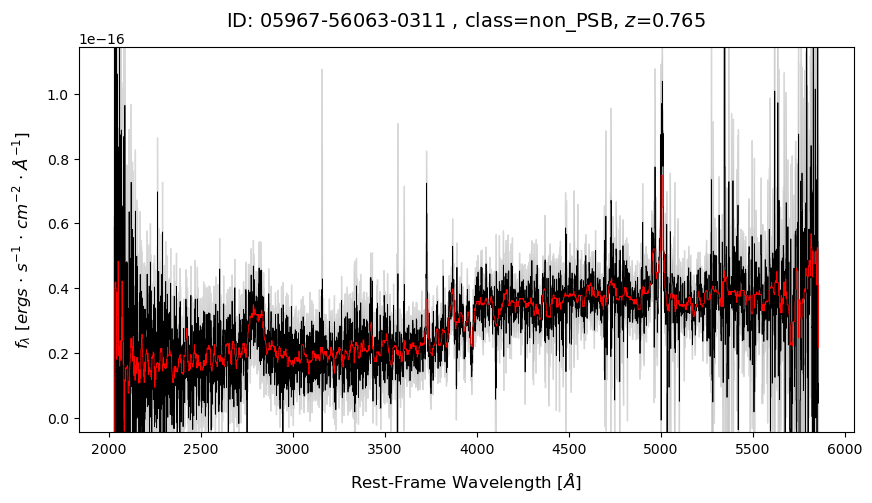

Successfully plotted 05967-56063-0311
--------------------------------------------------


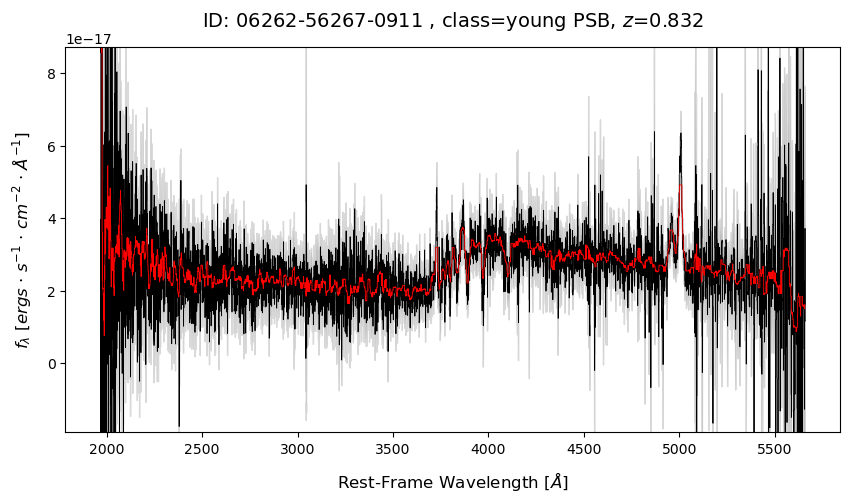

Successfully plotted 06262-56267-0911
--------------------------------------------------
Paused after 3 plots.


In [25]:

interesting_df = classified_eBOSS_sample[
    classified_eBOSS_sample.set_index(['PLATE', 'FIBER']).index.isin(interesting_galaxies)
]

# my computer is not the best piece of technology... I am going to start with printing three spectra at a time to lessen the load
max_plots_to_run = 3

# now we will save all relevant info from each row
for index, source in interesting_df.reset_index().iterrows():
    if index >= max_plots_to_run:
        print(f"Paused after {max_plots_to_run} plots.")
        break

    plate = int(source['PLATE'])
    mjd = int(source['MJD'])
    fiber = int(source['FIBER'])
    key = source['PMF_STRING']
    z = source['Z']
    classification = source['PSB_CLASS']

    # now we can query the spectra from the actual SDSS archive
    try:
        spec = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiber)

        if spec is not None:
            hdu = spec[0]

            # now we can save all of the spectral data that we have hopefully located
            # first: flux
            flux_density_factor = hdu[1].data['flux']
            flux_density = 10**(-17) * flux_density_factor 

            # second: flux error
            ivar = hdu[1].data['ivar']
            flux_density_err = np.zeros_like(flux_density)
            good = ivar > 0 # avoiding ever dividing by zero!!!!
            flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])

            # third: wavelength
            log_wav = hdu[1].data['loglam']
            wavelength = 10**log_wav

            # okay now we have to convert the spectrum from the observed wavelength to the rest frame using redshifts
            rest_frame_wavelength = wavelength / (1 + z)
            rest_frame_flux_density = flux_density * (1 + z)
            rest_frame_flux_density_err = flux_density_err * (1 + z)

            # Smoothing:
            med_smooth_rest_flux = median_filter(rest_frame_flux_density, size=20, mode='reflect')

            # now we can make the plots!!!
            plt.figure(figsize=(10, 5))

            plt.title(f"ID: {key} , class={classification}, $z$={z:.3f}", fontsize=14, pad=15)
            plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=12, labelpad=10)
            plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=12, labelpad=10)

            # spectral line data
            plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.6)
            plt.step(rest_frame_wavelength, med_smooth_rest_flux, where='mid', color='red', linewidth=0.6)

            # flux errors
            upper = rest_frame_flux_density + rest_frame_flux_density_err
            lower = rest_frame_flux_density - rest_frame_flux_density_err
            plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.15)

            # UPDATE: as Christy stated, our y-axis of our spectra need to be optimzed so the range of y-values on each spectra is as small and detailed as possible
            # so, we will be focusing on a clean wavelength window to avoid any massive noise lines
            clean_window = (rest_frame_wavelength > 3800) & (rest_frame_wavelength < 7000)
            window_flux = rest_frame_flux_density[clean_window]
            window_wav = rest_frame_wavelength[clean_window]

            if len(window_flux) > 0:
                # find the true baseline of the galaxy's continuum
                continuum_median = np.median(window_flux)

                # find the lowest noise dips
                absolute_floor = np.percentile(window_flux, 1)

                # find the peak of real emissions
                absolute_peak = np.percentile(window_flux, 99.5)

                # calculate the height of the tallest feature
                feature_height = absolute_peak - continuum_median

                # set the limits:
                # first, the floor goes down to the real lowest noise point, plus a buffer
                ymin = absolute_floor - (abs(absolute_floor) * 0.2 if absolute_floor < 0 else continuum_median * 0.1)

                # the ceiling matches the height of the tallest feature
                ymax = continuum_median + (feature_height * 1.2)

                plt.ylim(ymin, ymax)

            fig_name = f'{key}_spectrum.png'
            file_path = os.path.join('..', 'plots', fig_name)

            plt.show()
            plt.close()
            print(f"Successfully plotted {key}\n" + "-"*50)

        else:
            print(f"Warning: No spectral data returned for {key}.\n" + "-"*50)

    except Exception as e:
        print(f"Failed to retrieve spectrum for {key}: {e}\n" + "-"*50)

We can zoom in a bit to make out any prominent spectral features

In [22]:
# compute the median flux value (which approximates the continuum level emission)
median_flux = np.median(rest_frame_flux_density)

# ~~~~~~~~~~~~~~ try updating the lower and upper factors ~~~~~~~~~~~~~~
lower_y_lim = median_flux * 0.25
upper_y_lim = median_flux * 3
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [23]:
# ~~~~~~~~~~ try with a different line or modify window size  ~~~~~~~~~~
spectral_feature = 'H-delta'          # name of the spectral feature
spectral_feature_wavelength = 4101    # rest-frame wavlength in Angstroms

lower_x_lim = spectral_feature_wavelength - 500   # create a window around the spectral feature
upper_x_lim = spectral_feature_wavelength + 500   # ''
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

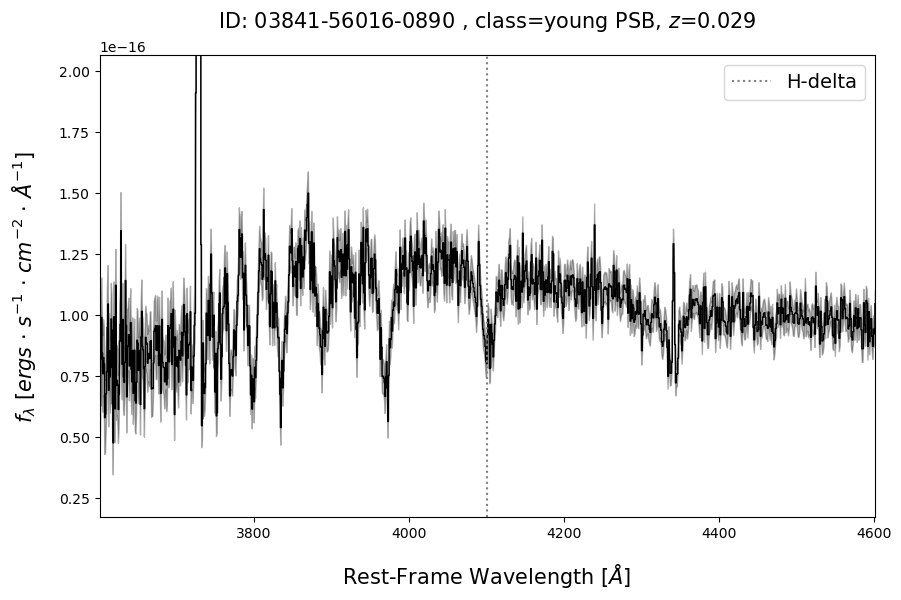

In [27]:
# initializing our figure
plt.figure(figsize=(10,6))

# labeling our axes
plt.title(f"ID: {key} , class={classification}, $z$={z:.3f}",fontsize=15, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# main spectral data
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=1.0)

# flux errors shown by shaded region
upper = rest_frame_flux_density + flux_density_err
lower = rest_frame_flux_density - flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.3)

# highlight the spectral feature the figure is centered on
plt.axvline(spectral_feature_wavelength, color='grey', linestyle='dotted', label=spectral_feature)
plt.legend(fontsize=14, loc='upper right')

# apply scaling factors to y-axis
plt.ylim(lower_y_lim, upper_y_lim)

# limiting our x-axis to focus on a particular spectral feature
plt.xlim(lower_x_lim, upper_x_lim)

# saving and displaying figure
fig_name = f'{key}_spectrum.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

It also might be interesting to manually input the galaxy's ID (the numbers for the PLATE, MJD, and FIBER) into [SkyServer SDSS](https://skyserver.sdss.org/dr19/VisualTools/quickobj?plate=03615&mjd=55445&fiber=0570).

This online tool allows you to see an image of the galaxy and gives more info on its spectral features!

/var/folders/ym/_9lx38h91lsd4vs8fr41_zsw0000gn/T/ipykernel_18297/3557107822.py:117: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(np.percentile(fallback_flux, 1), np.max(fallback_flux) * 1.3)


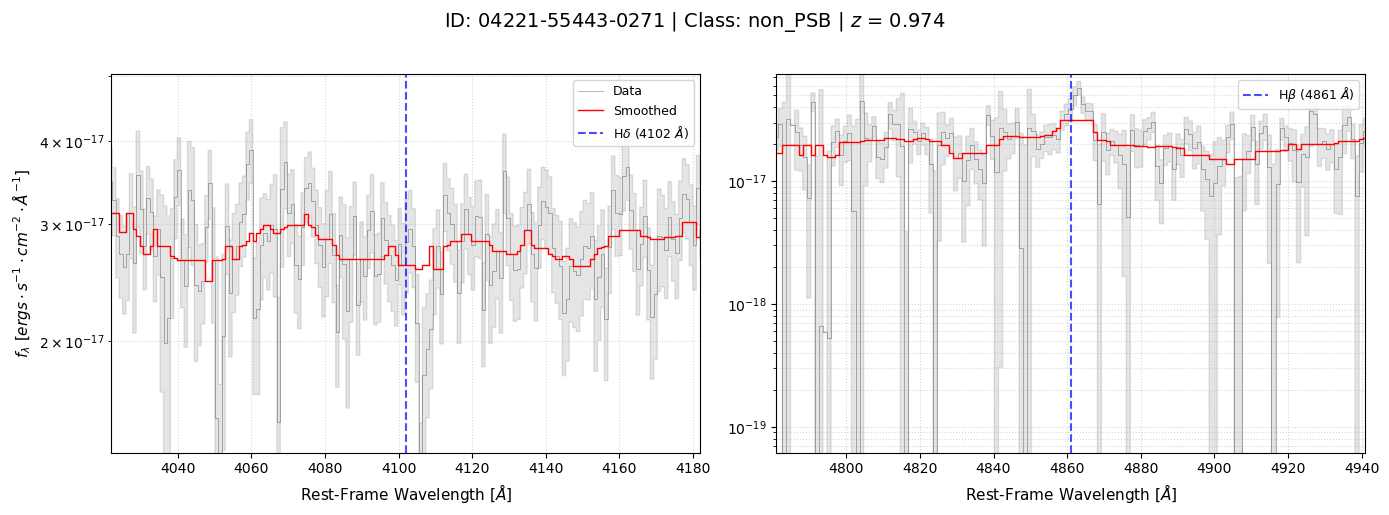

Successfully plotted 04221-55443-0271 using target: H$\beta$
--------------------------------------------------


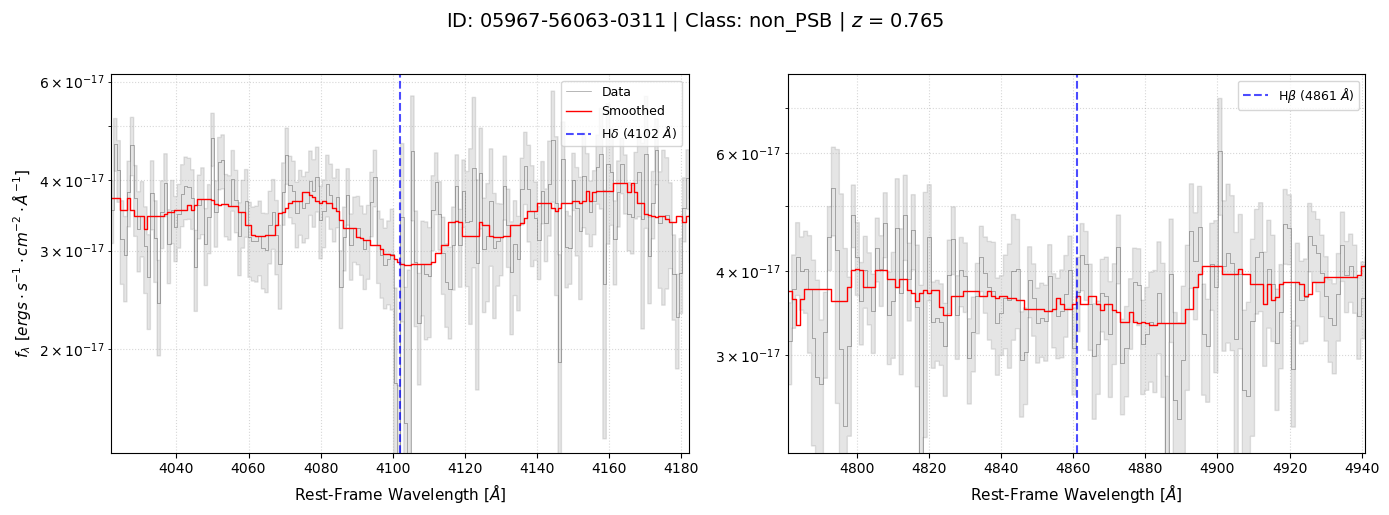

Successfully plotted 05967-56063-0311 using target: H$\beta$
--------------------------------------------------


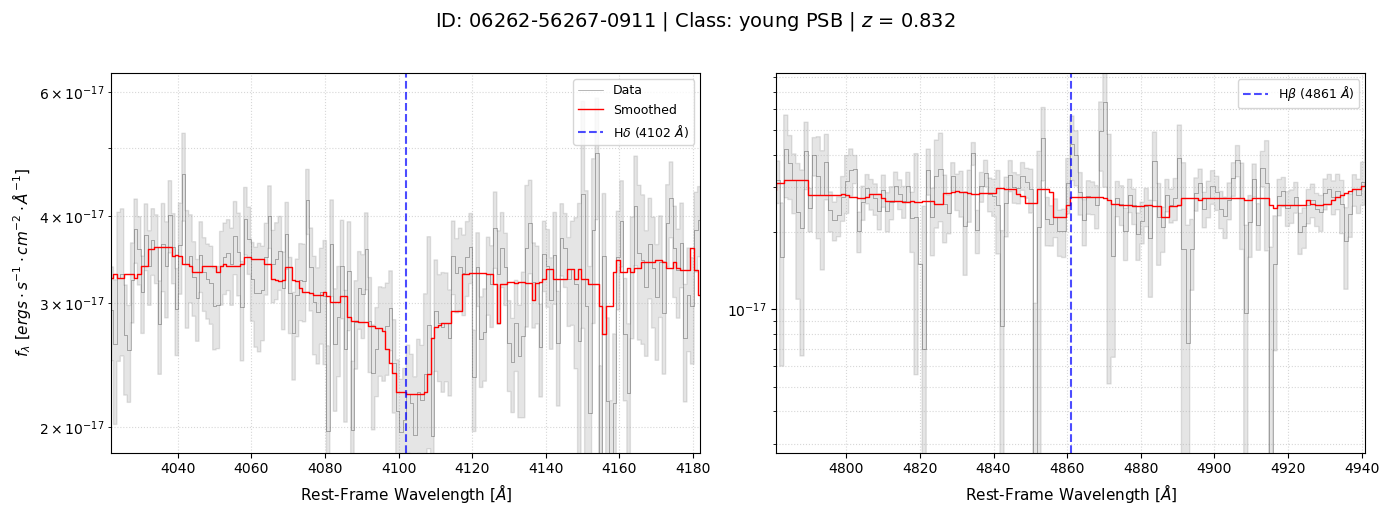

Successfully plotted 06262-56267-0911 using target: H$\beta$
--------------------------------------------------
Paused after 3 plots.


In [13]:
# Zooming into key identifying features

interesting_df = classified_eBOSS_sample[
    classified_eBOSS_sample.set_index(['PLATE', 'FIBER']).index.isin(interesting_galaxies)
]

# So, since most of our galaxies are so far redshifted that they have no h-alpha data
# we need our code to switch to h-beta or OIII data if h-alpha data isn't avaiable

# first we will define the central rest-frame wavelengths that we are interested in
H_delta = 4102.0 # should have data for h-delta for all of our galaxies regardless
H_alpha = 6563.0
H_beta = 4861.0
OIII = 5007.0 # just using the main line of the doublet here

# set the window half-width to zoom in around our target wavelengths well
half_width = 80

max_plots_to_run = 3 # just don't want to cycle through all 1600 galaxies right now...

for index, source in interesting_df.reset_index().iterrows():
    if index >= max_plots_to_run:
        print(f"Paused after {max_plots_to_run} plots.")
        break

    plate = int(source['PLATE'])
    mjd = int(source['MJD'])
    fiber = int(source['FIBER'])
    key = source['PMF_STRING']
    z = source['Z']
    classification = source['PSB_CLASS']

    try:
        spec = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiber)

        if spec is not None:
            hdu = spec[0]

            flux_density_factor = hdu[1].data['flux']
            ivar = hdu[1].data['ivar']
            log_wav = hdu[1].data['loglam']

            # okay now time for math corrections...
            wavelength = 10**log_wav

            err_raw = np.zeros_like(flux_density_factor)
            good = ivar > 0
            err_raw[good] = 1.0 / np.sqrt(ivar[good])

            # applying scaling
            flux_density = 10**(-17) * flux_density_factor
            flux_density_err = 10**(-17) * err_raw

            # okay now convert the observed frames to rest frames using redshift
            rest_frame_wavelength = wavelength / (1 + z)
            rest_frame_flux_density = flux_density * (1 + z)
            rest_frame_flux_density_err = flux_density_err * (1 + z)

            # smoothing
            med_smooth_rest_flux = median_filter(rest_frame_flux_density, size=15, mode='reflect')

            # Conditional logic (for galaxies with no h-alpha/h-beta data)
            max_observed_rest_wavelength = np.max(rest_frame_wavelength)
            
            # we select the secondary window based on data availability
            if max_observed_rest_wavelength > (H_alpha + half_width):
                right_target = H_alpha
                right_label = r'H$\alpha$'
            elif max_observed_rest_wavelength > (H_beta + half_width):
                right_target = H_beta
                right_label = r'H$\beta$'
            else:
                right_target = OIII
                right_label = r'[OIII]'

            # okay now we can start setting up out windows
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f"ID: {key} | Class: {classification} | $z$ = {z:.3f}", fontsize=14, y=1.02)

            upper = rest_frame_flux_density + rest_frame_flux_density_err
            lower = rest_frame_flux_density - rest_frame_flux_density_err

            # panel one; h-delta
            ax1.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', alpha=0.4, linewidth=0.5, label='Data')
            ax1.step(rest_frame_wavelength, med_smooth_rest_flux, where='mid', color='red', linewidth=1.0, label='Smoothed')
            ax1.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.1)
            
            ax1.set_xlim(H_delta - half_width, H_delta + half_width)
            ax1.axvline(H_delta, color='blue', linestyle='--', alpha=0.7, label=r'H$\delta$ (4102 $\AA$)')
            ax1.set_xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=11)
            ax1.set_ylabel(r'$f_{\lambda}$ [$ergs \cdot s^{-1} \cdot cm^{-2} \cdot \AA^{-1}$]', fontsize=11)
            ax1.set_yscale('log', nonpositive='clip')
            ax1.grid(True, which="both", linestyle=':', alpha=0.5)
            ax1.legend(loc='upper right', fontsize=9)

            # here we optimize Y-axis limits specifically for the H-delta window
            hd_window = (rest_frame_wavelength > (H_delta - half_width)) & (rest_frame_wavelength < (H_delta + half_width))
            hd_flux = rest_frame_flux_density[hd_window]
            if len(hd_flux) > 0:
                ax1.set_ylim(np.percentile(hd_flux, 1), np.max(hd_flux) * 1.3)

            # panel two; h-alpha (or whatever we have avaiable)
            ax2.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', alpha=0.4, linewidth=0.5)
            ax2.step(rest_frame_wavelength, med_smooth_rest_flux, where='mid', color='red', linewidth=1.0)
            ax2.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.1)
            
            ax2.set_xlim(right_target - half_width, right_target + half_width)
            ax2.axvline(right_target, color='blue', linestyle='--', alpha=0.7, label=f'{right_label} ({right_target:.0f} $\AA$)')
            ax2.set_xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=11)
            ax2.set_yscale('log', nonpositive='clip')
            ax2.grid(True, which="both", linestyle=':', alpha=0.5)
            ax2.legend(loc='upper right', fontsize=9)
            
            fallback_window = (rest_frame_wavelength > (right_target - half_width)) & (rest_frame_wavelength < (right_target + half_width))
            fallback_flux = rest_frame_flux_density[fallback_window]
            if len(fallback_flux) > 0:
                ax2.set_ylim(np.percentile(fallback_flux, 1), np.max(fallback_flux) * 1.3)

            plt.tight_layout()

            plt.show()
            plt.close(fig) # Explicitly close the figure reference to free up system RAM
            print(f"Successfully plotted {key} using target: {right_label}\n" + "-"*50)

        else:
            print(f"Warning: No spectral data returned for {key}.\n" + "-"*50)

    except Exception as e:
        print(f"Failed to retrieve spectrum for {key}: {e}\n" + "-"*50)
            